# ARIMA with Seasonal Differencing Using Alternative Estimators

The `ARIMA` class supports several parameter estimation methods beyond the
default `statespace` approach: `hannan_rissanen`, `yule_walker`, `burg`, and
`innovations`. These methods are faster and do not require numerical
optimisation, making them useful for quick estimation or as starting-value
generators.

Previously, all four methods rejected any model with a non-zero seasonal
period — even models whose only seasonal component is differencing (i.e.
`seasonal_order=(0, D, 0, s)` with `D > 0`). This notebook demonstrates that
they now correctly handle seasonal differencing while still raising a clear
error for seasonal AR or MA terms.

In [1]:
%matplotlib inline

In [2]:
import warnings

import matplotlib.pyplot as plt
import pandas as pd
import statsmodels.api as sm
from statsmodels.tsa.arima.model import ARIMA

plt.rc("figure", figsize=(14, 5))
plt.rc("font", size=12)
warnings.filterwarnings("ignore")

## Data: Mauna Loa Atmospheric CO₂

We use the classic Keeling Curve dataset, which records monthly mean
atmospheric CO₂ concentrations (in parts per million by volume) measured at
the Mauna Loa Observatory, Hawaii. The series exhibits two clear features:

- A long-run upward trend driven by fossil-fuel emissions.
- A strong annual seasonal cycle caused by Northern Hemisphere plant growth
  (CO₂ is drawn down each summer and rises each winter).

These features make the CO₂ series a natural candidate for a model with both
regular and seasonal differencing.

In [3]:
co2 = sm.datasets.co2.load_pandas().data
co2 = co2.resample("ME").mean().ffill()   # resample to month-end, fill one gap
print(sm.datasets.co2.NOTE)

::

    Number of observations: 2225
    Number of variables: 2
    Variable name definitions:

        date - sample date in YYMMDD format
        co2 - CO2 Concentration ppmv

    The data returned by load_pandas contains the dates as the index.



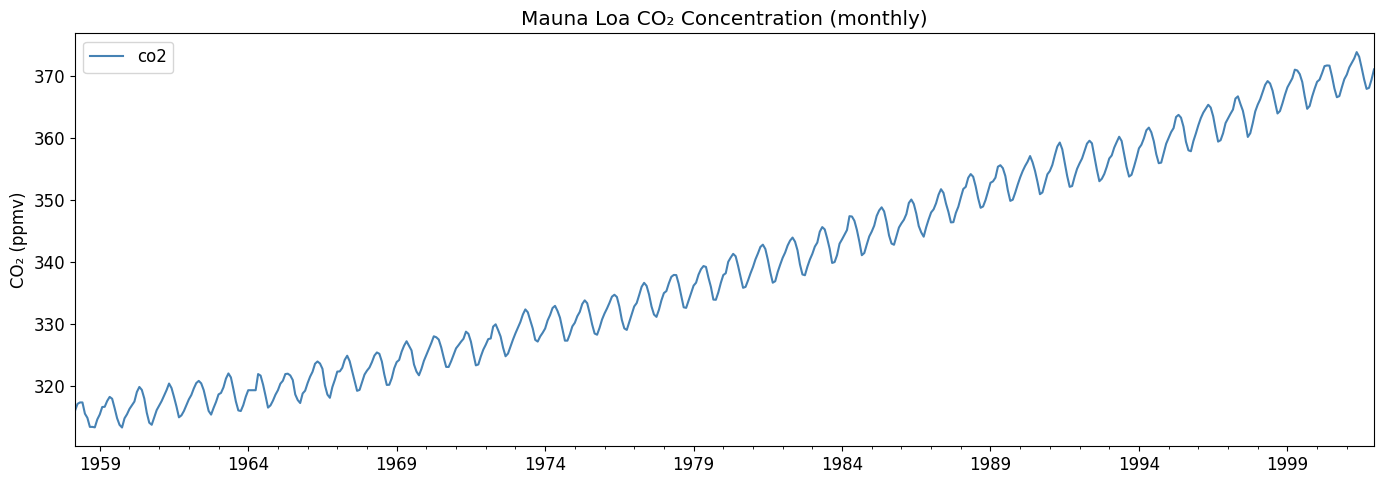

In [4]:
fig, ax = plt.subplots()
co2.plot(ax=ax, color="steelblue")
ax.set_title("Mauna Loa CO₂ Concentration (monthly)")
ax.set_ylabel("CO₂ (ppmv)")
ax.set_xlabel("")
plt.tight_layout()

## Choosing a Model

A single seasonal difference (D=1, s=12) removes the annual seasonal pattern,
and a single regular difference (d=1) removes the linear trend. After both
differences the series is approximately stationary, so low-order AR and MA
terms are sufficient.

We use `ARIMA(1, 1, 1)(0, 1, 0, 12)` as the main specification. For
estimators that only support pure-AR models (`yule_walker`, `burg`) we use
`ARIMA(2, 0, 0)(0, 1, 0, 12)` instead.

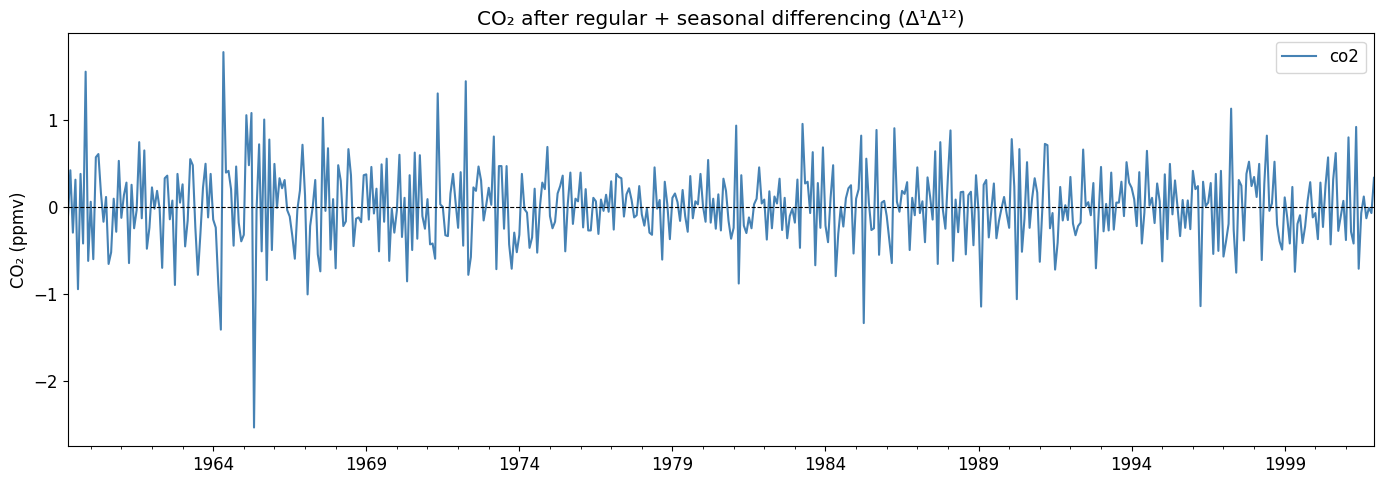

In [5]:
co2_diff = co2.diff().diff(12).dropna()

fig, ax = plt.subplots()
co2_diff.plot(ax=ax, color="steelblue")
ax.set_title("CO₂ after regular + seasonal differencing (Δ¹Δ¹²)")
ax.set_ylabel("CO₂ (ppmv)")
ax.set_xlabel("")
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
plt.tight_layout()

## Fitting with Alternative Estimators

### Hannan-Rissanen

`hannan_rissanen` fits ARMA models via a three-step least-squares procedure.
It is fast and closed-form. We pass `seasonal_order=(0, 1, 0, 12)` so the
series is seasonally differenced before estimation.

In [6]:
res_hr = ARIMA(co2, order=(1, 1, 1), seasonal_order=(0, 1, 0, 12)).fit(
    method="hannan_rissanen"
)
print(res_hr.params.round(4))

ValueError: Hannan-Rissanen estimator does not support seasonal components.

### Yule-Walker

`yule_walker` is limited to pure-AR models but supports seasonal differencing
in the same way.

In [7]:
res_yw = ARIMA(co2, order=(2, 0, 0), seasonal_order=(0, 1, 0, 12)).fit(
    method="yule_walker"
)
print(res_yw.params.round(4))

ValueError: Yule-Walker estimator does not support seasonal components.

### Statespace (reference)

We also fit the same ARIMA(1,1,1)(0,1,0,12) specification with the default
`statespace` method. This produces full MLE estimates with standard errors,
serving as a numerical reference for the alternative estimators.

In [ ]:
res_ss = ARIMA(co2, order=(1, 1, 1), seasonal_order=(0, 1, 0, 12)).fit(
    method="statespace"
)
res_ss.summary()

## Comparing Parameter Estimates

The alternative estimators are consistent but not efficient — they trade some
accuracy for speed. The table below compares the AR and MA coefficients
from Hannan-Rissanen against the statespace MLE reference.

In [ ]:
comparison = pd.DataFrame({
    "hannan_rissanen": res_hr.params.drop("sigma2").round(4),
    "statespace (MLE)": res_ss.params.drop("sigma2").round(4),
})
print(comparison.to_string())

## Residual Diagnostics

A quick look at the Hannan-Rissanen residuals confirms there is no remaining
structure in the series.

In [ ]:
fig = res_hr.plot_diagnostics(figsize=(14, 8))
fig.suptitle("Hannan-Rissanen residual diagnostics", y=1.01)
plt.tight_layout()

## What Is Still Not Supported

Seasonal AR and MA terms (`P > 0` or `Q > 0`) require the full statespace
machinery. The alternative estimators will raise a `ValueError` with a clear
message:

In [ ]:
try:
    ARIMA(co2, order=(1, 0, 0), seasonal_order=(1, 0, 0, 12)).fit(
        method="hannan_rissanen"
    )
except ValueError as e:
    print(type(e).__name__, ":", e)

## Summary

| Estimator | Seasonal diff (D>0) | Seasonal AR/MA (P,Q>0) |
|---|---|---|
| `hannan_rissanen` | ✓ supported | ✗ raises ValueError |
| `yule_walker` | ✓ supported | ✗ raises ValueError |
| `burg` | ✓ supported | ✗ raises ValueError |
| `innovations` | ✓ supported | ✗ raises ValueError |
| `innovations_mle` | ✓ supported | ✓ supported |
| `statespace` | ✓ supported | ✓ supported |

For full SARIMA models with seasonal AR or MA components, use
`method="statespace"` or `method="innovations_mle"`.